# Token Clustering & Centroid Distance Analysis

1. **Token clustering:** Do prompts cluster by token count? If so, is that clustering correlated with condition?
2. **Centroid distance vs expected random distance:** How does the distance between emotional/neutral cluster centroids compare to the expected distance between a random emotional and random neutral sample?

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR  = BASE_DIR / 'analysis'

# ── Load token counts ──────────────────────────────────────────────────────
tokens = pd.read_csv(DATA_DIR / 'token_counts.csv')
print(f'Token counts loaded: {len(tokens)} prompts')
print(tokens.head())

Token counts loaded: 40 prompts
   condition  prompt_index  n_tokens                        title
0  emotional             0       477                      medical
1  emotional             1       469                          NaN
2  emotional             2       477  Natural disaster evacuation
3  emotional             3       445   Mountain Climbing accident
4  emotional             4       471                   House Fire


## §1 — Token count by condition

In [31]:
for cond in ['emotional', 'neutral']:
    v = tokens[tokens.condition == cond]['n_tokens']
    print(f'{cond:10s}  n={len(v):3d}  mean={v.mean():.1f}  std={v.std():.1f}  min={v.min()}  max={v.max()}')

e = tokens[tokens.condition == 'emotional']['n_tokens']
n = tokens[tokens.condition == 'neutral']['n_tokens']
u, p = mannwhitneyu(e, n, alternative='two-sided')
print(f'\nMann-Whitney U={u:.1f}  p={p:.4f}')
print(f'Token counts differ between conditions: {p < 0.05}')

emotional   n= 20  mean=457.4  std=22.3  min=409  max=485
neutral     n= 20  mean=452.6  std=25.8  min=379  max=499

Mann-Whitney U=217.5  p=0.6454
Token counts differ between conditions: False


In [32]:
# K-means on token count alone — does it recover condition?
X_tok = tokens[['n_tokens']].values
y_tok = (tokens['condition'] == 'emotional').astype(int).values

scaler = StandardScaler()
X_tok_s = scaler.fit_transform(X_tok)
km = KMeans(n_clusters=2, n_init=50, random_state=42)
pred = km.fit_predict(X_tok_s)

cm = confusion_matrix(y_tok, pred)
acc = max((cm[0,0]+cm[1,1])/cm.sum(), (cm[0,1]+cm[1,0])/cm.sum())
ari = adjusted_rand_score(y_tok, pred)

print(f'Clustering on token count alone:')
print(f'  Accuracy: {acc:.4f}  (chance = 0.50)')
print(f'  ARI:      {ari:.4f}')
print(f'\nIf accuracy ≈ 0.50, token count does not separate conditions.')

Clustering on token count alone:
  Accuracy: 0.5250  (chance = 0.50)
  ARI:      -0.0221

If accuracy ≈ 0.50, token count does not separate conditions.


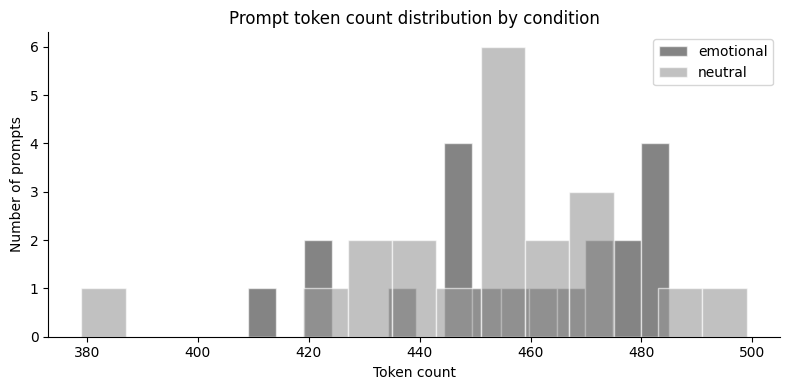

In [33]:
# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
for cond, color in [('emotional', '#333333'), ('neutral', '#999999')]:
    vals = tokens[tokens.condition == cond]['n_tokens']
    ax.hist(vals, bins=15, alpha=0.6, color=color, label=cond, edgecolor='white')
ax.set_xlabel('Token count')
ax.set_ylabel('Number of prompts')
ax.set_title('Prompt token count distribution by condition')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## §2 — Centroid distance vs expected random distance

For the best feature from the main analysis, compare:
- The distance between the emotional and neutral centroids (from k-means)
- The expected distance between a randomly drawn emotional sample and a randomly drawn neutral sample

If the centroid distance is much smaller than the expected random distance, the clusters overlap heavily. If they are comparable, the clustering captures most of the separation.

In [43]:
# ── Load feature data (matching 70b_blocks_analysis.ipynb) ────────────────
DATA_DIR  = BASE_DIR / 'data'

FEATURE_DIR = DATA_DIR / 'longer70b'
RUNS = ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
BEST_FEATURE = 'core_power.throttle__slope'

dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = FEATURE_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'Total trials: {len(df_all)}')
print(f'Feature: {BEST_FEATURE}')

Loaded 8 runs: ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
Total trials: 320
Feature: core_power.throttle__slope


/var/folders/h6/72885xfn72j09dqwjl2d30yw0000gn/T/ipykernel_15075/2930413343.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d['run'] = run


In [44]:
# ── Configuration ──────────────────────────────────────────────────────────
N_PAIRS      = 100_000
N_BOOTSTRAP  = 1000
SEED         = 42
rng = np.random.default_rng(SEED)

feat_vals = df_all[BEST_FEATURE].dropna().values
labels = df_all.loc[df_all[BEST_FEATURE].notna(), 'condition'].values

e_vals = feat_vals[labels == 'emotional']
n_vals = feat_vals[labels == 'neutral']

print(f'Feature: {BEST_FEATURE}')
print(f'Samples: {len(e_vals)} emotional, {len(n_vals)} neutral')
print(f'Pairs sampled: {N_PAIRS:,}')
print(f'Bootstrap iterations: {N_BOOTSTRAP:,}')

# ── Basic statistics ───────────────────────────────────────────────────────
e_mean, e_std, e_median = np.mean(e_vals), np.std(e_vals, ddof=1), np.median(e_vals)
n_mean, n_std, n_median = np.mean(n_vals), np.std(n_vals, ddof=1), np.median(n_vals)

print(f'\n{"="*60}')
print(f'DESCRIPTIVE STATISTICS')
print(f'{"="*60}')
print(f'{"":15s}  {"Mean":>12s}  {"SD":>12s}  {"Median":>12s}')
print(f'{"Emotional":15s}  {e_mean:12.4f}  {e_std:12.4f}  {e_median:12.4f}')
print(f'{"Neutral":15s}  {n_mean:12.4f}  {n_std:12.4f}  {n_median:12.4f}')

# ── Centroid distance ──────────────────────────────────────────────────────
centroid_dist = abs(e_mean - n_mean)
direction = '↑E' if e_mean > n_mean else '↑N'

print(f'\n{"="*60}')
print(f'CENTROID DISTANCE')
print(f'{"="*60}')
print(f'  |mean_E - mean_N|  = {centroid_dist:.4f}  ({direction})')

# Bootstrap CI for centroid distance
boot_dists = []
for _ in range(N_BOOTSTRAP):
    e_boot = rng.choice(e_vals, size=len(e_vals), replace=True)
    n_boot = rng.choice(n_vals, size=len(n_vals), replace=True)
    boot_dists.append(abs(np.mean(e_boot) - np.mean(n_boot)))
boot_dists = np.array(boot_dists)
ci_lo, ci_hi = np.percentile(boot_dists, [2.5, 97.5])
print(f'  95% bootstrap CI   = [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  Bootstrap mean     = {np.mean(boot_dists):.4f}')

# ── Effect size (Cohen's d) ───────────────────────────────────────────────
pooled_std = np.sqrt((e_std**2 + n_std**2) / 2)
cohens_d = centroid_dist / pooled_std if pooled_std > 0 else np.nan

print(f'\n{"="*60}')
print(f'EFFECT SIZE')
print(f'{"="*60}')
print(f"  Cohen's d          = {cohens_d:.4f}")
print(f'  Pooled SD          = {pooled_std:.4f}')
print(f'  Interpretation     : ', end='')
if cohens_d < 0.2:
    print('negligible (< 0.2)')
elif cohens_d < 0.5:
    print('small (0.2 – 0.5)')
elif cohens_d < 0.8:
    print('medium (0.5 – 0.8)')
else:
    print('large (≥ 0.8)')

# Bootstrap CI for Cohen's d
boot_ds = []
for _ in range(N_BOOTSTRAP):
    e_boot = rng.choice(e_vals, size=len(e_vals), replace=True)
    n_boot = rng.choice(n_vals, size=len(n_vals), replace=True)
    ps = np.sqrt((np.var(e_boot, ddof=1) + np.var(n_boot, ddof=1)) / 2)
    if ps > 0:
        boot_ds.append(abs(np.mean(e_boot) - np.mean(n_boot)) / ps)
boot_ds = np.array(boot_ds)
d_lo, d_hi = np.percentile(boot_ds, [2.5, 97.5])
print(f"  95% bootstrap CI   = [{d_lo:.4f}, {d_hi:.4f}]")

# ── Random pairwise distances ─────────────────────────────────────────────
e_samples_cross = rng.choice(e_vals, size=N_PAIRS)
n_samples_cross = rng.choice(n_vals, size=N_PAIRS)
cross_dists = np.abs(e_samples_cross - n_samples_cross)

e_pairs_1 = rng.choice(e_vals, size=N_PAIRS)
e_pairs_2 = rng.choice(e_vals, size=N_PAIRS)
within_e_dists = np.abs(e_pairs_1 - e_pairs_2)

n_pairs_1 = rng.choice(n_vals, size=N_PAIRS)
n_pairs_2 = rng.choice(n_vals, size=N_PAIRS)
within_n_dists = np.abs(n_pairs_1 - n_pairs_2)

within_all_dists = np.concatenate([within_e_dists, within_n_dists])

mean_cross   = np.mean(cross_dists)
mean_within  = np.mean(within_all_dists)
mean_within_e = np.mean(within_e_dists)
mean_within_n = np.mean(within_n_dists)

print(f'\n{"="*60}')
print(f'PAIRWISE DISTANCES ({N_PAIRS:,} random pairs)')
print(f'{"="*60}')
print(f'  E[|X_e - X_n|]  cross-condition      = {mean_cross:.4f}  (median {np.median(cross_dists):.4f})')
print(f'  E[|X_e - X_e\'|] within emotional     = {mean_within_e:.4f}  (median {np.median(within_e_dists):.4f})')
print(f'  E[|X_n - X_n\'|] within neutral        = {mean_within_n:.4f}  (median {np.median(within_n_dists):.4f})')
print(f'  E[|X - X\'|]     within combined       = {mean_within:.4f}  (median {np.median(within_all_dists):.4f})')

# ── Key ratios ─────────────────────────────────────────────────────────────
ratio_centroid_over_cross = centroid_dist / mean_cross if mean_cross > 0 else np.nan
ratio_cross_over_within  = mean_cross / mean_within if mean_within > 0 else np.nan
ratio_centroid_over_within = centroid_dist / mean_within if mean_within > 0 else np.nan

print(f'\n{"="*60}')
print(f'KEY RATIOS')
print(f'{"="*60}')
print(f'  centroid / cross-condition  = {ratio_centroid_over_cross:.4f}')
print(f'    (fraction of cross distance explained by mean shift)')
print(f'  cross / within             = {ratio_cross_over_within:.4f}')
print(f'    (>1 means cross-condition pairs are farther apart than within)')
print(f'  centroid / within          = {ratio_centroid_over_within:.4f}')
print(f'    (signal-to-noise: centroid shift relative to within-group spread)')

# ── Overlap statistics ─────────────────────────────────────────────────────
# What fraction of cross-condition pairs have the "wrong" ordering?
if direction == '↑E':
    frac_correct = np.mean(e_samples_cross > n_samples_cross)
else:
    frac_correct = np.mean(n_samples_cross > e_samples_cross)

# Overlap coefficient: fraction of cross pairs closer than median within pair
overlap_frac = np.mean(cross_dists < np.median(within_all_dists))

print(f'\n{"="*60}')
print(f'OVERLAP STATISTICS')
print(f'{"="*60}')
print(f'  P(e > n) if ↑E, P(n > e) if ↑N = {frac_correct:.4f}')
print(f'    (0.50 = complete overlap, 1.0 = perfect separation)')
print(f'  Fraction of cross pairs closer than median within-pair distance = {overlap_frac:.4f}')
print(f'    (high = heavy overlap between conditions)')

# ── Summary ────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'SUMMARY for {BEST_FEATURE}')
print(f'{"="*60}')
print(f'  Direction         : {direction}')
print(f'  Centroid distance : {centroid_dist:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f"  Cohen's d         : {cohens_d:.4f}  [{d_lo:.4f}, {d_hi:.4f}]")
print(f'  Cross/within      : {ratio_cross_over_within:.4f}')
print(f'  P(correct order)  : {frac_correct:.4f}')

Feature: core_power.throttle__slope
Samples: 160 emotional, 160 neutral
Pairs sampled: 100,000
Bootstrap iterations: 1,000

DESCRIPTIVE STATISTICS
                         Mean            SD        Median
Emotional           2379.1149      943.5718     2441.1992
Neutral             2883.0147      917.0466     3132.2984

CENTROID DISTANCE
  |mean_E - mean_N|  = 503.8998  (↑N)
  95% bootstrap CI   = [294.5475, 690.9145]
  Bootstrap mean     = 497.5918

EFFECT SIZE
  Cohen's d          = 0.5416
  Pooled SD          = 930.4037
  Interpretation     : medium (0.5 – 0.8)
  95% bootstrap CI   = [0.3301, 0.7601]

PAIRWISE DISTANCES (100,000 random pairs)
  E[|X_e - X_n|]  cross-condition      = 1136.8397  (median 972.5466)
  E[|X_e - X_e'|] within emotional     = 1077.1607  (median 935.3161)
  E[|X_n - X_n'|] within neutral        = 1016.5088  (median 825.5773)
  E[|X - X'|]     within combined       = 1046.8348  (median 879.0996)

KEY RATIOS
  centroid / cross-condition  = 0.4432
    (fraction

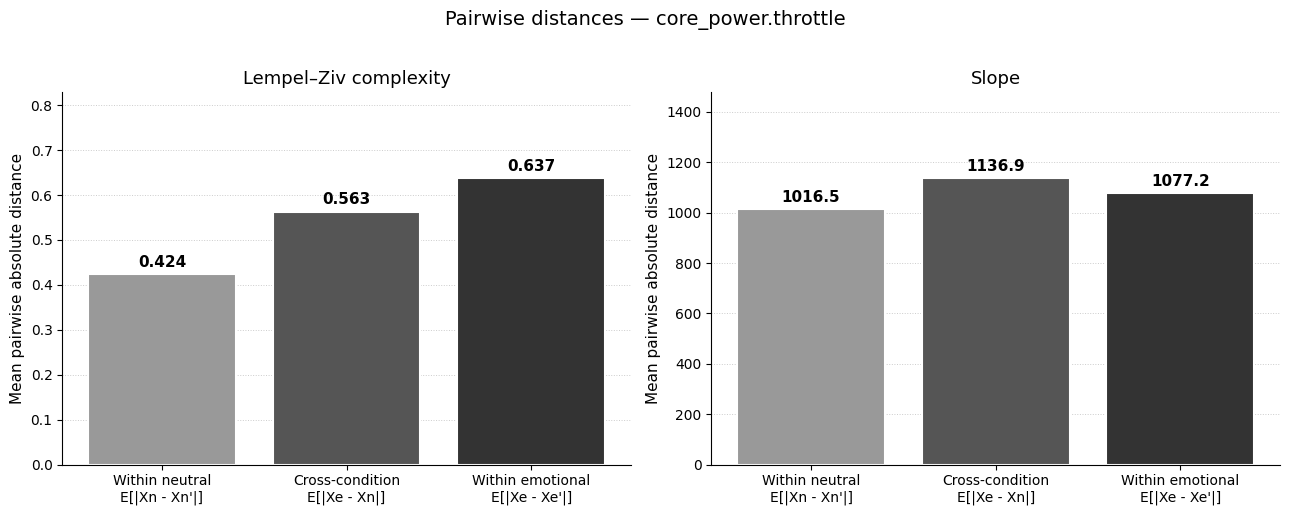

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = ['Within neutral\nE[|Xn - Xn\'|]',
              'Cross-condition\nE[|Xe - Xn|]',
              'Within emotional\nE[|Xe - Xe\'|]']
colors = ['#999999', '#555555', '#333333']

# ── LZ complexity ──────────────────────────────────────────────────────────
vals_lz = [0.4236, 0.5631, 0.6374]
ax = axes[0]
bars = ax.bar(range(3), vals_lz, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals_lz):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Mean pairwise absolute distance', fontsize=11)
ax.set_title('Lempel–Ziv complexity', fontsize=13)
ax.set_ylim(0, max(vals_lz) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

# ── Slope ──────────────────────────────────────────────────────────────────
vals_slope = [1016.5, 1136.9, 1077.2]
ax = axes[1]
bars = ax.bar(range(3), vals_slope, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals_slope):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Mean pairwise absolute distance', fontsize=11)
ax.set_title('Slope', fontsize=13)
ax.set_ylim(0, max(vals_slope) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

fig.suptitle('Pairwise distances — core_power.throttle', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

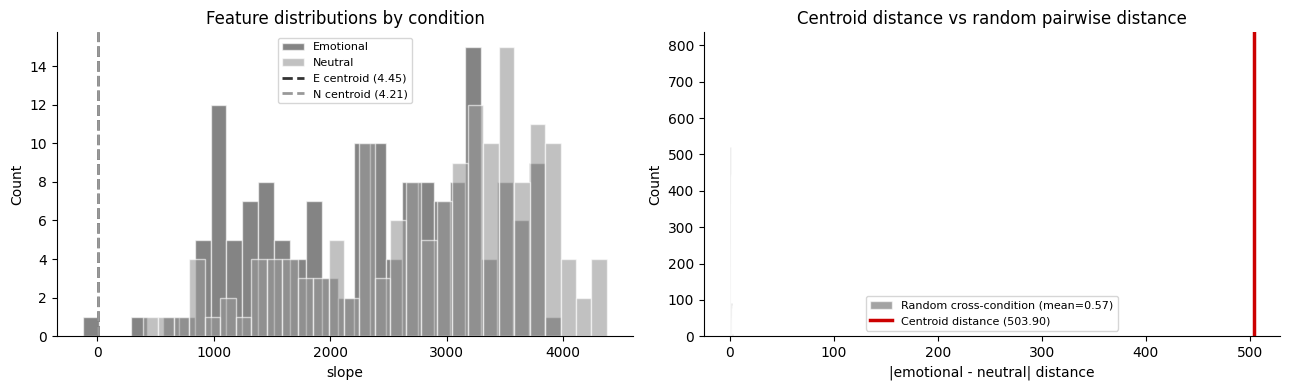

In [46]:
# Visualise the distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: feature distributions
ax = axes[0]
ax.hist(e_vals, bins=30, alpha=0.6, color='#333333', label='Emotional', edgecolor='white')
ax.hist(n_vals, bins=30, alpha=0.6, color='#999999', label='Neutral', edgecolor='white')
ax.axvline(centroid_e, color='#333333', ls='--', lw=2, label=f'E centroid ({centroid_e:.2f})')
ax.axvline(centroid_n, color='#999999', ls='--', lw=2, label=f'N centroid ({centroid_n:.2f})')
ax.set_xlabel(BEST_FEATURE.split('__')[-1])
ax.set_ylabel('Count')
ax.set_title('Feature distributions by condition')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Right: distance distributions
ax = axes[1]
ax.hist(random_dists, bins=40, alpha=0.6, color='#666666', edgecolor='white',
        label=f'Random cross-condition (mean={mean_random_dist:.2f})')
ax.axvline(centroid_dist, color='#cc0000', ls='-', lw=2.5,
           label=f'Centroid distance ({centroid_dist:.2f})')
ax.set_xlabel('|emotional - neutral| distance')
ax.set_ylabel('Count')
ax.set_title('Centroid distance vs random pairwise distance')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()